# N1 · flow matching: 少步也能生成 (Flow vs DDPM)

> 配套 13.2-L1 · 训速度场, 不同步数 (2/4/8/16/32) ODE 采样, 看少步也能生成 (质量 vs 步数曲线),
> 体会 flow matching 比 DDPM 省步。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import flow_matching as fm
print('flow_matching 就绪')

flow_matching 就绪


## 1. 训练速度场 (L1): 学「噪声→数据」的速度, MSE 回归

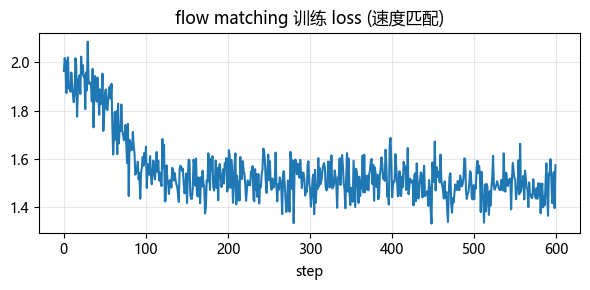

loss 1.965 → 1.574


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
torch.manual_seed(0)
x1 = fm.make_two_moons(n=512, seed=1)
model = fm.build_velocity_field()
losses = fm.train_flow_matching(model, x1, epochs=600)
plt.figure(figsize=(6,3)); plt.plot(losses); plt.title('flow matching 训练 loss (速度匹配)')
plt.xlabel('step'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"loss {losses[0]:.3f} → {losses[-1]:.3f}")

## 2. ODE 采样: 不同步数都能生成 (少步是卖点, L1)

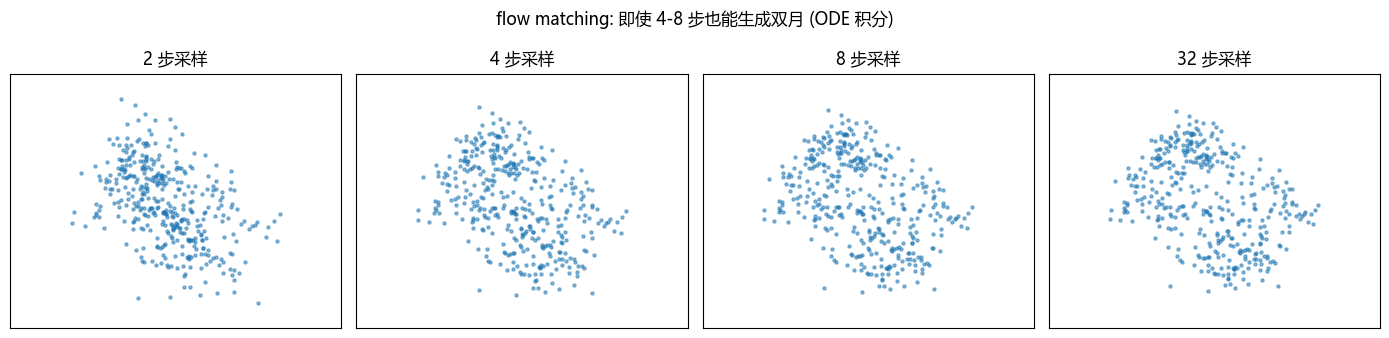

In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, axes = plt.subplots(1, 4, figsize=(14,3.4))
for ax, s in zip(axes, [2, 4, 8, 32]):
    gen = fm.sample(model, n=400, steps=s, seed=3)
    ax.scatter(gen[:,0], gen[:,1], s=5, alpha=0.5); ax.set_title(f'{s} 步采样'); ax.axis('equal')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('flow matching: 即使 4-8 步也能生成双月 (ODE 积分)'); plt.tight_layout(); plt.show()

## 3. 质量 vs 步数曲线 (L4: 步数是部署旋钮)

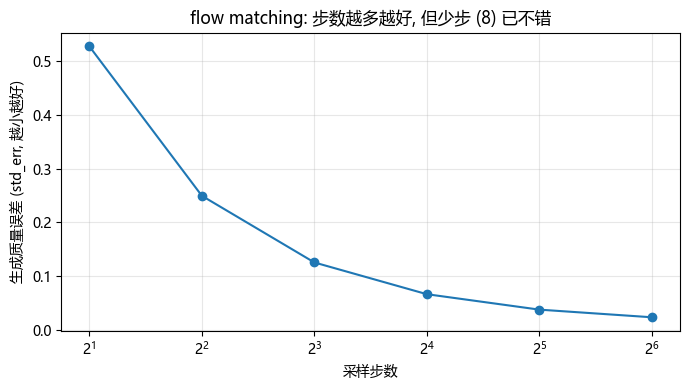

    2 步: std_err 0.5273
    4 步: std_err 0.2495
    8 步: std_err 0.1256
   16 步: std_err 0.0666
   32 步: std_err 0.0379
   64 步: std_err 0.0237
→ 8 步质量已不错 (DDPM 同质量需更多步)。下一步 N2: reflow 拉直, 让更少步也行。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
q = fm.quality_vs_steps(model, x1, step_list=(2,4,8,16,32,64))
steps = [r['steps'] for r in q]; errs = [r['std_err'] for r in q]
plt.figure(figsize=(7,4)); plt.plot(steps, errs, 'o-')
plt.xlabel('采样步数'); plt.ylabel('生成质量误差 (std_err, 越小越好)')
plt.title('flow matching: 步数越多越好, 但少步 (8) 已不错'); plt.grid(alpha=0.3); plt.xscale('log', base=2)
plt.tight_layout(); plt.show()
for r in q: print(f"  {r['steps']:>3} 步: std_err {r['std_err']}")
print("→ 8 步质量已不错 (DDPM 同质量需更多步)。下一步 N2: reflow 拉直, 让更少步也行。")

## 4. 反思
你看到 flow matching 用很少步 (4-8) 就能生成, 比 DDPM 省步。带走:
- flow matching 学速度场, ODE 积分采样; 步数 = 积分精度 (你 EE 的 ODE 直觉)。
- 路径越直, 少步质量越好 (L2)。下一步 N2: reflow 把路径拉得更直。